In [ ]:
#%pip install chembl_webresource_client

In [2]:
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.DataStructs import BulkTanimotoSimilarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from chembl_webresource_client.new_client import new_client

In [ ]:
# Step 1 — load ZINC250K candidates
url        = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df         = pd.read_csv(url)
candidates = df["smiles"].tolist()[:100000]
print(f"Candidates loaded: {len(candidates)}")

# Step 2 — load ChEMBL HMGCR reference
activity      = new_client.activity
acts          = activity.filter(
                    target_chembl_id="CHEMBL1781",
                    standard_type="IC50"
                ).only("canonical_smiles")
chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
print(f"ChEMBL reference compounds: {len(chembl_smiles)}")

Candidates loaded: 100000
ChEMBL reference compounds: 735


In [15]:
# Step 3 — fingerprint generator (created once, reused)
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi):
    try:
        mol = Chem.MolFromSmiles(smi.strip())
        if mol is None: return None
        return gen.GetFingerprint(mol)
    except:
        return None

# Step 4 — encode reference set
print("Encoding reference...")
ref_fps = [fp for fp in [encode(s) for s in chembl_smiles] if fp is not None]
print(f"Valid reference fps: {len(ref_fps)}")

# Step 5 — encode candidates (list comprehension — fastest in CPython)
print("Encoding candidates...")
candidate_fps = [(smi, fp) for smi, fp in
                 ((smi, encode(smi)) for smi in candidates)
                 if fp is not None]
print(f"Valid candidates: {len(candidate_fps)}")

# Step 6 — score using BulkTanimotoSimilarity (C++ call — fastest available)
print("Scoring...")
results = [
    {"smiles": smi, "tanimoto": max(BulkTanimotoSimilarity(fp, ref_fps))}
    for smi, fp in candidate_fps
]

df_results = pd.DataFrame(results)
print(f"Scored: {len(df_results)}")
print(df_results["tanimoto"].describe())

Encoding reference...
Valid reference fps: 735
Encoding candidates...
Valid candidates: 100000
Scoring...
Scored: 100000
count    100000.000000
mean          0.224507
std           0.055829
min           0.064935
25%           0.187500
50%           0.217949
75%           0.253731
max           0.689655
Name: tanimoto, dtype: float64


In [16]:
print(f"Hits >0.40: {(df_results['tanimoto'] > 0.40).sum()}")
print(f"Hits >0.50: {(df_results['tanimoto'] > 0.50).sum()}")
print(f"Hits >0.60: {(df_results['tanimoto'] > 0.60).sum()}")

# show top 10
print(df_results.nlargest(10, "tanimoto"))

Hits >0.40: 891
Hits >0.50: 92
Hits >0.60: 9
                                                  smiles  tanimoto
84383             O=C(Nc1ccccc1NC(=O)c1cccnc1)c1ccccc1\n  0.689655
97914             O=C(Nc1ccc(O)cc1)C(=O)Nc1nc2ccccc2s1\n  0.682927
18633           COc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1OC\n  0.666667
55777          C[NH+](C)Cc1ccc(C(=O)Nc2nc3ccccc3s2)cc1\n  0.666667
4429                          O=C(Nc1ccc(O)cc1)c1ccsc1\n  0.633333
78367     COc1cc(C(=O)Nc2cc(Cl)c(O)c(Cl)c2)ccc1OC(C)=O\n  0.627907
42424             CC1CCN(S(=O)(=O)c2ccccc2-c2ccno2)CC1\n  0.625000
95420  COc1ccc(NC(=O)c2ccccc2NC(=O)/C(C)=C/c2ccccc2)c...  0.625000
21203       Cc1cccc(C(=O)Nc2ccccc2NC(=O)c2cccc(C)c2)c1\n  0.620690
14043           O=C(Nc1nc2ccccc2s1)c1ccc(N2CCNC2=O)cc1\n  0.600000


In [12]:
# Step 7 — filter by Tanimoto threshold
hits = df_results[df_results["tanimoto"] > 0.40].copy()

print(f"Hits >0.40: {len(hits)}")
print(f"Hits >0.60: {(df_results['tanimoto'] > 0.60).sum()}")
print(f"Hits >0.80: {(df_results['tanimoto'] > 0.80).sum()}")

Hits >0.40: 891
Hits >0.60: 9
Hits >0.80: 0


In [13]:
# Step 8 — compute descriptors on hits only
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return {}
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {"mw": round(mw,2), "logp": round(logp,2),
            "hbd": hbd, "hba": hba, "qed": round(qed,3),
            "violations": viol}

# Step 9 — PAINS filter
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains  = FilterCatalog(params)

def has_pains(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return True
    return pains.GetFirstMatch(mol) is not None

hits = hits.copy()
desc_df            = hits["smiles"].apply(get_descriptors).apply(pd.Series)
hits               = pd.concat([hits, desc_df], axis=1)
hits["pains_flag"] = hits["smiles"].apply(has_pains)

passed_lipinski = (hits["violations"] == 0).sum()
pains_flagged   = hits["pains_flag"].sum()
clean           = ((hits["violations"] == 0) & (~hits["pains_flag"])).sum()

print("Descriptor summary:")
print(hits[["tanimoto","mw","logp","qed","violations"]].describe())
print(f"Passed Lipinski: {passed_lipinski}")
print(f"PAINS flagged:   {pains_flagged}")
print(f"Clean:           {clean}")

Descriptor summary:
         tanimoto          mw        logp         qed  violations
count  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.446311  341.254220    3.416756    0.727521    0.038159
std      0.044354   53.529694    1.067713    0.145001    0.191688
min      0.402439  150.180000   -1.960000    0.224000    0.000000
25%      0.414634  309.265000    2.790000    0.636000    0.000000
50%      0.431818  339.360000    3.480000    0.758000    0.000000
75%      0.462963  373.455000    4.185000    0.842000    0.000000
max      0.689655  498.460000    6.480000    0.946000    1.000000
Passed Lipinski: 857
PAINS flagged:   23
Clean:           834


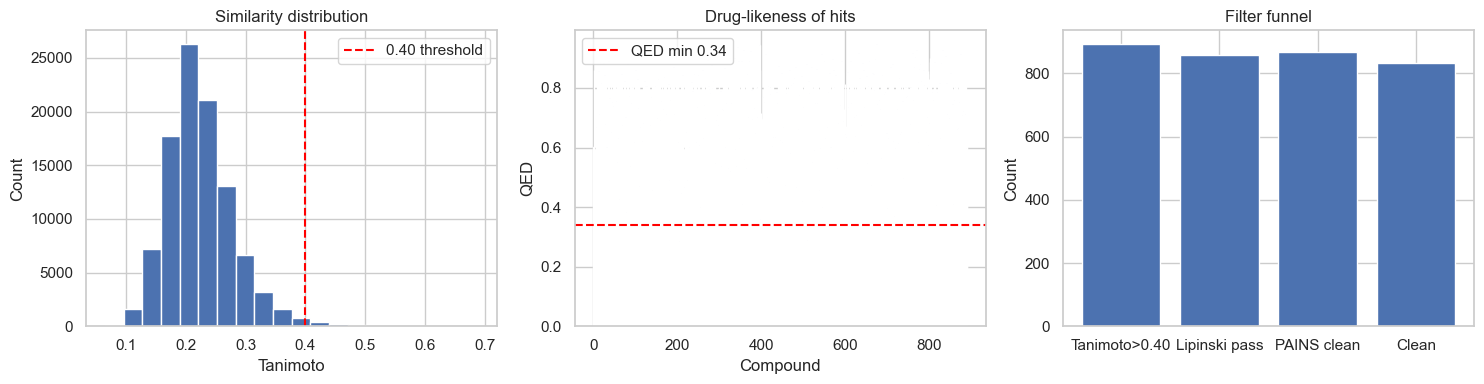

In [14]:
# Step 10 — visualisations
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Tanimoto distribution
axes[0].hist(df_results["tanimoto"], bins=20)
axes[0].axvline(0.40, color="red", linestyle="--", label="0.40 threshold")
axes[0].set(title="Similarity distribution", xlabel="Tanimoto", ylabel="Count")
axes[0].legend()

# Plot 2 — QED of hits
axes[1].bar(range(len(hits)), hits["qed"])
axes[1].axhline(0.34, color="red", linestyle="--", label="QED min 0.34")
axes[1].set(title="Drug-likeness of hits", xlabel="Compound", ylabel="QED")
axes[1].legend()

# Plot 3 — Filter funnel
axes[2].bar(["Tanimoto>0.40", "Lipinski pass", "PAINS clean", "Clean"],
    [len(hits), passed_lipinski, len(hits)-pains_flagged, clean]
)
axes[2].set(title="Filter funnel", ylabel="Count")

plt.tight_layout()
plt.show()

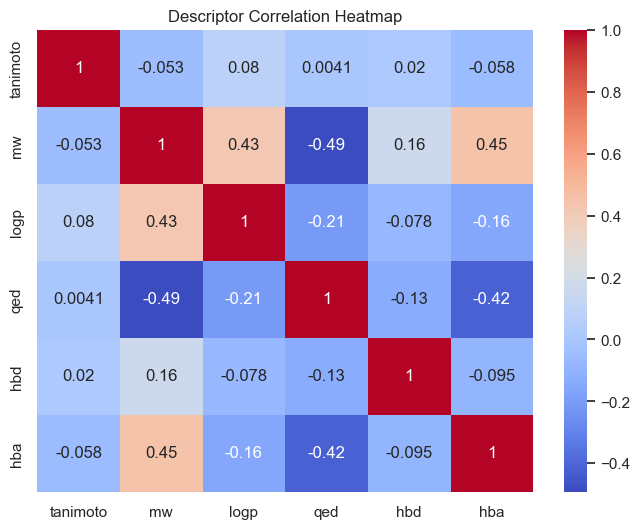

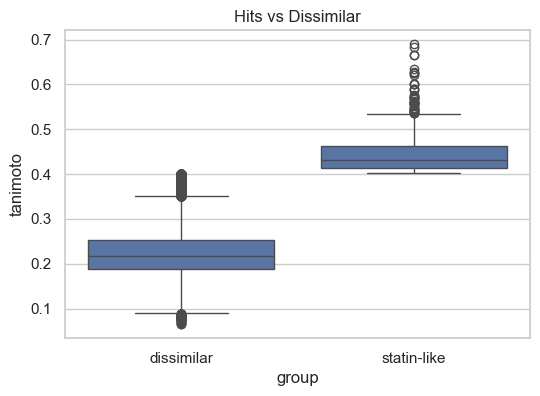

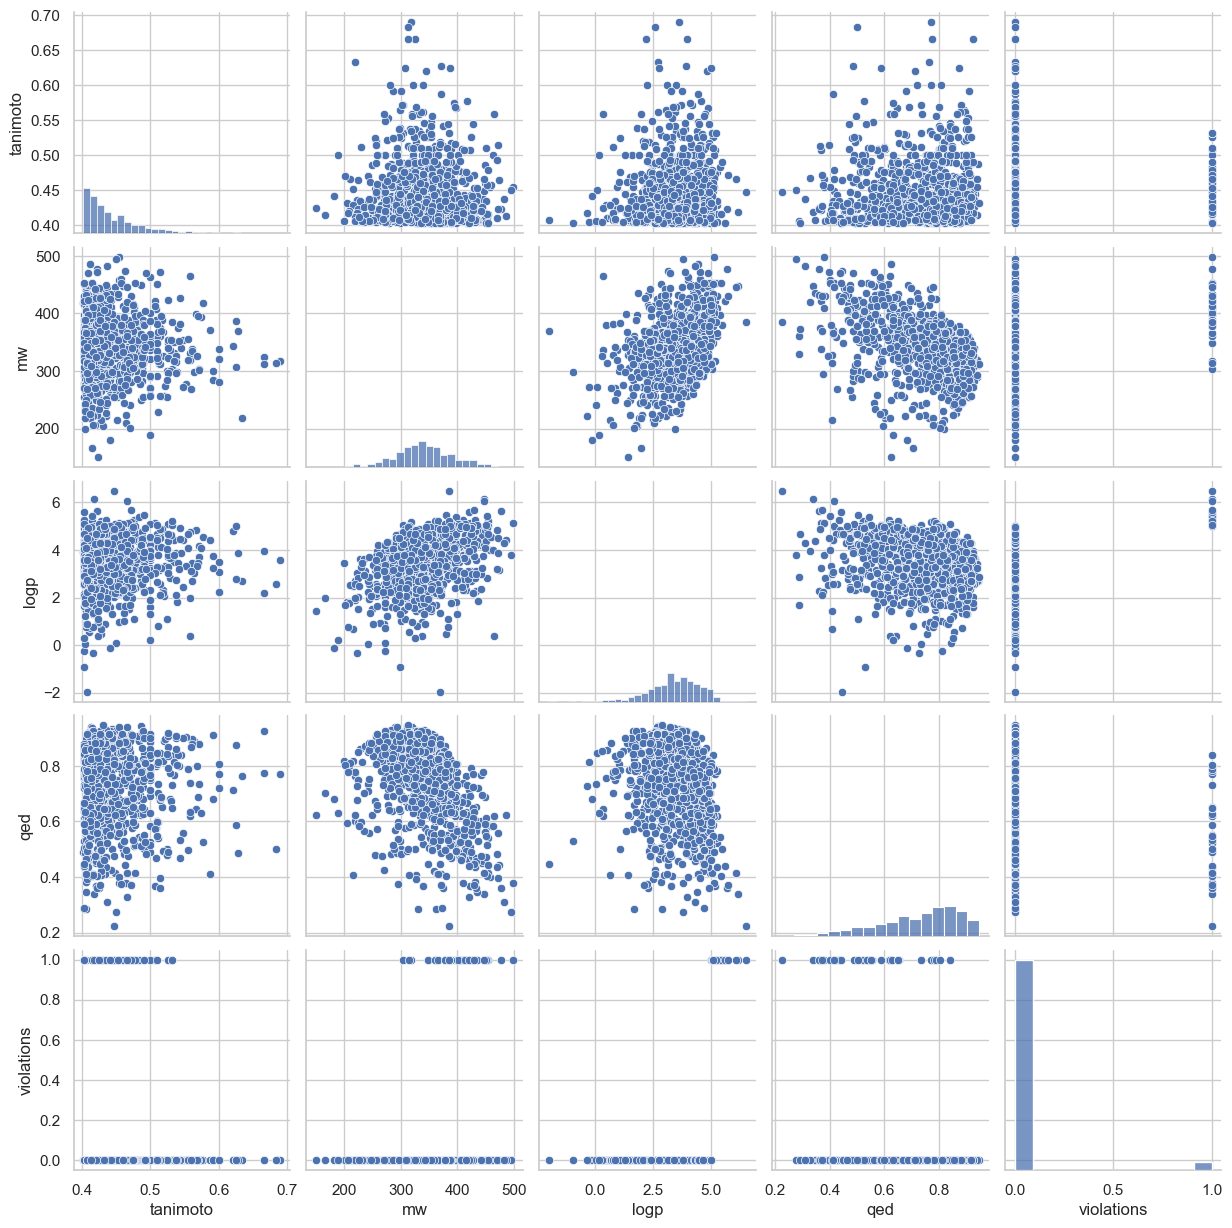

In [11]:
# Step 11 — feature analysis

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    hits[["tanimoto","mw","logp","qed","hbd","hba"]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Descriptor Correlation Heatmap")
plt.show()

# Hits vs dissimilar boxplot
df_results["group"] = df_results["tanimoto"].apply(
    lambda x: "statin-like" if x > 0.40 else "dissimilar"
)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_results, x="group", y="tanimoto")
plt.title("Hits vs Dissimilar")
plt.show()

# Pairplot on hits
if len(hits) > 1:
    sns.pairplot(hits[["tanimoto","mw","logp","qed","violations"]], diag_kind="hist")
    plt.show()